<a href="https://colab.research.google.com/github/FengruiJing/BioStatistics/blob/main/RQ1_overall_behavioral_usability_heat_bins.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#mount google drive
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


# RQ1: Overall behavioral usability under health-relevant heat-risk ranges

This notebook reuses the existing main-analysis daily sample and:

1. restricts to the <=1000 m urban / urban-adjacent sample  
2. builds 4 local heat-risk bins using `placekey × month_local` relative Tmax thresholds (`P75`, `P90`, `P97.5`)  
3. summarizes overall daily visitation by heat-risk bin  
4. builds within-park retention contrasts versus the reference bin  
5. produces national summary tables and one main figure  
6. repeats the same analysis in a dry-day sensitivity subset  

**Focus:** `visits_total_date` only.  
**Not included here:** daypart redistribution.


## 6) Repeats the same analysis in a dry-day sensitivity subset

In [2]:
# =========================================================
# RQ1
# Do urban parks retain overall behavioral usability when
# temperatures enter health-relevant heat-risk ranges?
#
# This script reuses the existing main-analysis daily sample and:
#      relative Tmax thresholds (P75, P90, P97.5)
#
# IMPORTANT
# - This script focuses on overall behavioral usability only:
#   visits_total_date
# - It does NOT analyze daypart redistribution here.
# - Thresholds are estimated from the active daily sample because the
#   current modeling-ready table already contains P90 / P95 thresholds,
#   but not P75 / P97.5.
# - If you later create externally fixed local thresholds (for example,
#   cell_key x month climatology), you can replace STEP 2 only.
# =========================================================

from pathlib import Path
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
base = Path("/content/gdrive/My Drive/Colab Notebooks")
derived_root = base / "_derived_nature_parks_mainmodel"

out_root = derived_root / "_results_rq1_overall_usability_heat_bins"
out_tables_root = out_root / "tables"
out_figures_root = out_root / "figures"
out_intermediate_root = out_root / "intermediate"

out_root.mkdir(parents=True, exist_ok=True)
out_tables_root.mkdir(parents=True, exist_ok=True)
out_figures_root.mkdir(parents=True, exist_ok=True)
out_intermediate_root.mkdir(parents=True, exist_ok=True)

# Prefer the already-restricted <=1000m daily sample created in Section 4.1.
# Fall back to the full modeling-ready daily sample if needed.
daily_1000m_path = (
    derived_root
    / "_results_4_1_descriptive"
    / "intermediate"
    / "daily_modelready_urban_adjacent_le_1000m.parquet"
)

in_daily_model_root = derived_root / "MainAnalysis_POI_Date_ModelReady_AnalysisMechanism"

# Outputs
qa_schema_csv = out_tables_root / "qa_schema_daily_sample.csv"
qa_sample_summary_csv = out_tables_root / "qa_sample_summary.csv"
heatbin_daily_path = out_intermediate_root / "daily_with_heat_bins_1000m.parquet"
heatbin_daily_dry_path = out_intermediate_root / "daily_with_heat_bins_dry_1000m.parquet"
heatbin_counts_csv = out_tables_root / "table_rq1_heatbin_counts.csv"
heatbin_desc_csv = out_tables_root / "table_rq1_daily_descriptive_by_heatbin.csv"
park_bin_summary_path = out_intermediate_root / "park_bin_visit_summary.parquet"
park_bin_contrast_path = out_intermediate_root / "park_bin_visit_retention_vs_ref.parquet"
park_bin_summary_dry_path = out_intermediate_root / "park_bin_visit_summary_dry.parquet"
park_bin_contrast_dry_path = out_intermediate_root / "park_bin_visit_retention_vs_ref_dry.parquet"
national_retention_csv = out_tables_root / "table_rq1_national_retention_vs_ref.csv"
national_retention_dry_csv = out_tables_root / "table_rq1_national_retention_vs_ref_dry.csv"
figure_main_png = out_figures_root / "figure_rq1_overall_visit_retention_by_heatbin.png"
figure_main_pdf = out_figures_root / "figure_rq1_overall_visit_retention_by_heatbin.pdf"

# Analysis settings
URBAN_DISTANCE_THRESHOLD_M = 1000.0
DRY_DAY_MM_THRESHOLD = 1.0
MIN_DAYS_IN_BIN = 3          # minimum park-days required in a bin
FIG_DPI = 500

# Heat-bin labels in order
BIN_ORDER = [
    "B1_ref_ltP75",
    "B2_P75_P90",
    "B3_P90_P97_5",
    "B4_geP97_5",
]

BIN_LABELS = {
    "B1_ref_ltP75": "Reference (<P75)",
    "B2_P75_P90": "P75–P90",
    "B3_P90_P97_5": "P90–P97.5",
    "B4_geP97_5": ">=P97.5",
}

In [4]:
con = duckdb.connect()
con.execute("PRAGMA threads=8;")
con.execute("PRAGMA enable_progress_bar;")
tmp_dir = (out_root / "_duckdb_tmp").as_posix()
con.execute(f"PRAGMA temp_directory='{tmp_dir}';")


def sql_path_list(paths):
    if len(paths) == 0:
        raise ValueError("Empty path list.")
    return "[" + ", ".join("'" + str(Path(p).as_posix()).replace("'", "''") + "'" for p in paths) + "]"


if daily_1000m_path.exists():
    daily_sql = f"read_parquet('{daily_1000m_path.as_posix()}')"
    active_daily_desc = str(daily_1000m_path)
else:
    daily_files = sorted(in_daily_model_root.rglob("main_analysis_daily_modelready.parquet"))
    if len(daily_files) == 0:
        raise FileNotFoundError(
            f"Cannot find either:\n- {daily_1000m_path}\n- any model-ready daily parquet under {in_daily_model_root}"
        )
    daily_sql = f"read_parquet({sql_path_list(daily_files)})"
    active_daily_desc = f"fallback full daily modelready under {in_daily_model_root}"

print("Active daily sample:", active_daily_desc)

# Required fields for RQ1 overall-usability analysis
required_cols = [
    "placekey",
    "local_date",
    "month_local",
    "visits_total_date",
    "tmax_day_c",
    "prcp_sum_day_mm",
    "dist_to_urban_area_m",
]

schema_df = con.execute(f"DESCRIBE SELECT * FROM {daily_sql}").fetchdf()
schema_df.to_csv(qa_schema_csv, index=False)
available_cols = schema_df["column_name"].tolist()
missing_cols = [c for c in required_cols if c not in available_cols]
if len(missing_cols) > 0:
    raise RuntimeError(f"Missing required fields in the active daily sample: {missing_cols}")

print("Schema QA saved:", qa_schema_csv)

# Basic sample QA
sample_summary = con.execute(f"""
SELECT
    COUNT(*) AS n_rows_raw,
    COUNT(DISTINCT placekey) AS n_parks_raw,
    COUNT(DISTINCT local_date) AS n_dates_raw,
    MIN(local_date) AS min_date,
    MAX(local_date) AS max_date,
    AVG(tmax_day_c) AS mean_tmax_day_c,
    AVG(visits_total_date) AS mean_visits_total_date
FROM {daily_sql}
""").fetchdf()
print(sample_summary)
sample_summary.to_csv(qa_sample_summary_csv, index=False)

Active daily sample: /content/gdrive/My Drive/Colab Notebooks/_derived_nature_parks_mainmodel/_results_4_1_descriptive/intermediate/daily_modelready_urban_adjacent_le_1000m.parquet
Schema QA saved: /content/gdrive/My Drive/Colab Notebooks/_derived_nature_parks_mainmodel/_results_rq1_overall_usability_heat_bins/tables/qa_schema_daily_sample.csv


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

   n_rows_raw  n_parks_raw  n_dates_raw   min_date   max_date  \
0    36830460       103321          419 2022-05-02 2024-09-30   

   mean_tmax_day_c  mean_visits_total_date  
0        27.162328               49.512573  


In [5]:
# We estimate placekey x month_local thresholds directly from the active
# daily sample to obtain 4 relative heat-risk bins:
#   B1: < P75
#   B2: P75 - <P90
#   B3: P90 - <P97.5
#   B4: >= P97.5

con.execute(f"""
COPY (
    WITH base_daily AS (
        SELECT
            placekey,
            CAST(local_date AS DATE) AS local_date,
            month_local,
            visits_total_date,
            tmax_day_c,
            prcp_sum_day_mm,
            dist_to_urban_area_m,
            location_name,
            city,
            region,
            state_abbr_final,
            park_type_heat4,
            park_feature_signature,
            tree_mean_park,
            tract_pop_density_km2,
            tract_median_hh_income,
            park_area_ha_main
        FROM {daily_sql}
        WHERE visits_total_date IS NOT NULL
          AND tmax_day_c IS NOT NULL
          AND dist_to_urban_area_m IS NOT NULL
          AND dist_to_urban_area_m <= {URBAN_DISTANCE_THRESHOLD_M}
    ),
    thresh AS (
        SELECT
            placekey,
            month_local,
            quantile_cont(tmax_day_c, 0.75) AS tmax_p75_pk_month,
            quantile_cont(tmax_day_c, 0.90) AS tmax_p90_pk_month,
            quantile_cont(tmax_day_c, 0.975) AS tmax_p97_5_pk_month
        FROM base_daily
        GROUP BY placekey, month_local
    )
    SELECT
        b.*,
        t.tmax_p75_pk_month,
        t.tmax_p90_pk_month,
        t.tmax_p97_5_pk_month,
        CASE
            WHEN b.tmax_day_c < t.tmax_p75_pk_month THEN 'B1_ref_ltP75'
            WHEN b.tmax_day_c < t.tmax_p90_pk_month THEN 'B2_P75_P90'
            WHEN b.tmax_day_c < t.tmax_p97_5_pk_month THEN 'B3_P90_P97_5'
            ELSE 'B4_geP97_5'
        END AS heat_risk_bin,
        CASE
            WHEN b.prcp_sum_day_mm IS NOT NULL AND b.prcp_sum_day_mm < {DRY_DAY_MM_THRESHOLD} THEN 1
            ELSE 0
        END AS is_dry_day
    FROM base_daily b
    INNER JOIN thresh t
    USING(placekey, month_local)
)
TO '{heatbin_daily_path.as_posix()}'
(FORMAT PARQUET, COMPRESSION 'SNAPPY');
""")

# Dry-day subset saved separately for sensitivity analysis
con.execute(f"""
COPY (
    SELECT *
    FROM read_parquet('{heatbin_daily_path.as_posix()}')
    WHERE is_dry_day = 1
)
TO '{heatbin_daily_dry_path.as_posix()}'
(FORMAT PARQUET, COMPRESSION 'SNAPPY');
""")

print("Saved full heat-bin daily table:", heatbin_daily_path)
print("Saved dry-day heat-bin daily table:", heatbin_daily_dry_path)

# Heat-bin count table
heatbin_counts = con.execute(f"""
SELECT
    heat_risk_bin,
    COUNT(*) AS n_park_days,
    COUNT(DISTINCT placekey) AS n_parks,
    COUNT(DISTINCT local_date) AS n_dates,
    AVG(tmax_day_c) AS mean_tmax_day_c,
    MIN(tmax_day_c) AS min_tmax_day_c,
    MAX(tmax_day_c) AS max_tmax_day_c,
    AVG(visits_total_date) AS mean_visits_total_date
FROM read_parquet('{heatbin_daily_path.as_posix()}')
GROUP BY heat_risk_bin
ORDER BY CASE heat_risk_bin
    WHEN 'B1_ref_ltP75' THEN 1
    WHEN 'B2_P75_P90' THEN 2
    WHEN 'B3_P90_P97_5' THEN 3
    WHEN 'B4_geP97_5' THEN 4
END
""").fetchdf()
heatbin_counts.to_csv(heatbin_counts_csv, index=False)
print("Saved:", heatbin_counts_csv)
print(heatbin_counts)

# Daily descriptive table (national park-day level)
heatbin_desc = con.execute(f"""
SELECT
    heat_risk_bin,
    COUNT(*) AS n_park_days,
    COUNT(DISTINCT placekey) AS n_parks,
    AVG(visits_total_date) AS mean_visits_total_date,
    median(visits_total_date) AS median_visits_total_date,
    AVG(tmax_day_c) AS mean_tmax_day_c,
    AVG(prcp_sum_day_mm) AS mean_prcp_sum_day_mm
FROM read_parquet('{heatbin_daily_path.as_posix()}')
GROUP BY heat_risk_bin
ORDER BY CASE heat_risk_bin
    WHEN 'B1_ref_ltP75' THEN 1
    WHEN 'B2_P75_P90' THEN 2
    WHEN 'B3_P90_P97_5' THEN 3
    WHEN 'B4_geP97_5' THEN 4
END
""").fetchdf()
heatbin_desc.to_csv(heatbin_desc_csv, index=False)
print("Saved:", heatbin_desc_csv)
print(heatbin_desc)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Saved full heat-bin daily table: /content/gdrive/My Drive/Colab Notebooks/_derived_nature_parks_mainmodel/_results_rq1_overall_usability_heat_bins/intermediate/daily_with_heat_bins_1000m.parquet
Saved dry-day heat-bin daily table: /content/gdrive/My Drive/Colab Notebooks/_derived_nature_parks_mainmodel/_results_rq1_overall_usability_heat_bins/intermediate/daily_with_heat_bins_dry_1000m.parquet


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Saved: /content/gdrive/My Drive/Colab Notebooks/_derived_nature_parks_mainmodel/_results_rq1_overall_usability_heat_bins/tables/table_rq1_heatbin_counts.csv
  heat_risk_bin  n_park_days  n_parks  n_dates  mean_tmax_day_c  \
0  B1_ref_ltP75     27478246   103313      419        25.726765   
1    B2_P75_P90      5449805   103290      419        30.390199   
2  B3_P90_P97_5      2664143   102929      419        32.208885   
3    B4_geP97_5      1238266   103321      417        33.954674   

   min_tmax_day_c  max_tmax_day_c  mean_visits_total_date  
0       -3.839621       47.177498               49.182607  
1        8.261896       48.152916               50.267583  
2        9.361597       49.119957               50.875426  
3       10.390253       50.497963               50.579707  


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Saved: /content/gdrive/My Drive/Colab Notebooks/_derived_nature_parks_mainmodel/_results_rq1_overall_usability_heat_bins/tables/table_rq1_daily_descriptive_by_heatbin.csv
  heat_risk_bin  n_park_days  n_parks  mean_visits_total_date  \
0  B1_ref_ltP75     27478246   103313               49.182607   
1    B2_P75_P90      5449805   103290               50.267583   
2  B3_P90_P97_5      2664143   102929               50.875426   
3    B4_geP97_5      1238266   103321               50.579707   

   median_visits_total_date  mean_tmax_day_c  mean_prcp_sum_day_mm  
0                      20.0        25.726765             33.899387  
1                      20.0        30.390199             15.093645  
2                      19.0        32.208885              9.725678  
3                      18.0        33.954674              8.301386  


In [6]:
# This is the core RQ1 table. It asks, within the same park,
# how much overall daily visitation is retained as conditions move from
# the reference bin to warmer heat-risk bins.

# Full sample
con.execute(f"""
COPY (
    SELECT
        placekey,
        ANY_VALUE(location_name) AS location_name,
        ANY_VALUE(city) AS city,
        ANY_VALUE(region) AS region,
        ANY_VALUE(state_abbr_final) AS state_abbr_final,
        ANY_VALUE(park_type_heat4) AS park_type_heat4,
        ANY_VALUE(tree_mean_park) AS tree_mean_park,
        ANY_VALUE(tract_pop_density_km2) AS tract_pop_density_km2,
        ANY_VALUE(tract_median_hh_income) AS tract_median_hh_income,
        ANY_VALUE(park_area_ha_main) AS park_area_ha_main,
        heat_risk_bin,
        COUNT(*) AS n_days_bin,
        AVG(visits_total_date) AS mean_visits_bin,
        median(visits_total_date) AS median_visits_bin,
        AVG(tmax_day_c) AS mean_tmax_bin,
        AVG(prcp_sum_day_mm) AS mean_prcp_bin
    FROM read_parquet('{heatbin_daily_path.as_posix()}')
    GROUP BY placekey, heat_risk_bin
)
TO '{park_bin_summary_path.as_posix()}'
(FORMAT PARQUET, COMPRESSION 'SNAPPY');
""")

# Dry-day sensitivity
con.execute(f"""
COPY (
    SELECT
        placekey,
        ANY_VALUE(location_name) AS location_name,
        ANY_VALUE(city) AS city,
        ANY_VALUE(region) AS region,
        ANY_VALUE(state_abbr_final) AS state_abbr_final,
        ANY_VALUE(park_type_heat4) AS park_type_heat4,
        ANY_VALUE(tree_mean_park) AS tree_mean_park,
        ANY_VALUE(tract_pop_density_km2) AS tract_pop_density_km2,
        ANY_VALUE(tract_median_hh_income) AS tract_median_hh_income,
        ANY_VALUE(park_area_ha_main) AS park_area_ha_main,
        heat_risk_bin,
        COUNT(*) AS n_days_bin,
        AVG(visits_total_date) AS mean_visits_bin,
        median(visits_total_date) AS median_visits_bin,
        AVG(tmax_day_c) AS mean_tmax_bin,
        AVG(prcp_sum_day_mm) AS mean_prcp_bin
    FROM read_parquet('{heatbin_daily_dry_path.as_posix()}')
    GROUP BY placekey, heat_risk_bin
)
TO '{park_bin_summary_dry_path.as_posix()}'
(FORMAT PARQUET, COMPRESSION 'SNAPPY');
""")

print("Saved full park-bin summary:", park_bin_summary_path)
print("Saved dry-day park-bin summary:", park_bin_summary_dry_path)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Saved full park-bin summary: /content/gdrive/My Drive/Colab Notebooks/_derived_nature_parks_mainmodel/_results_rq1_overall_usability_heat_bins/intermediate/park_bin_visit_summary.parquet
Saved dry-day park-bin summary: /content/gdrive/My Drive/Colab Notebooks/_derived_nature_parks_mainmodel/_results_rq1_overall_usability_heat_bins/intermediate/park_bin_visit_summary_dry.parquet


In [7]:
# pair_weight = min(n_days_ref, n_days_bin)
# visit_retention_pct = % change in mean visits relative to the reference bin
# visit_retention_log = log((bin+1)/(ref+1))

contrast_sql_template = """
COPY (
    WITH s AS (
        SELECT *
        FROM read_parquet('{summary_path}')
    ),
    ref AS (
        SELECT
            placekey,
            n_days_bin AS n_days_ref,
            mean_visits_bin AS mean_visits_ref,
            median_visits_bin AS median_visits_ref,
            mean_tmax_bin AS mean_tmax_ref,
            mean_prcp_bin AS mean_prcp_ref
        FROM s
        WHERE heat_risk_bin = 'B1_ref_ltP75'
          AND n_days_bin >= {min_days}
    ),
    nonref AS (
        SELECT *
        FROM s
        WHERE heat_risk_bin IN ('B2_P75_P90', 'B3_P90_P97_5', 'B4_geP97_5')
          AND n_days_bin >= {min_days}
    )
    SELECT
        n.placekey,
        n.location_name,
        n.city,
        n.region,
        n.state_abbr_final,
        n.park_type_heat4,
        n.tree_mean_park,
        n.tract_pop_density_km2,
        n.tract_median_hh_income,
        n.park_area_ha_main,

        n.heat_risk_bin,
        r.n_days_ref,
        n.n_days_bin,
        LEAST(r.n_days_ref, n.n_days_bin) AS pair_weight,

        r.mean_visits_ref,
        n.mean_visits_bin,
        r.median_visits_ref,
        n.median_visits_bin,
        r.mean_tmax_ref,
        n.mean_tmax_bin,
        r.mean_prcp_ref,
        n.mean_prcp_bin,

        (n.mean_visits_bin - r.mean_visits_ref) AS diff_mean_visits,
        CASE
            WHEN r.mean_visits_ref > 0
            THEN 100.0 * (n.mean_visits_bin / r.mean_visits_ref - 1.0)
            ELSE NULL
        END AS visit_retention_pct,
        LN((n.mean_visits_bin + 1.0) / (r.mean_visits_ref + 1.0)) AS visit_retention_log
    FROM nonref n
    INNER JOIN ref r
    USING(placekey)
    WHERE LEAST(r.n_days_ref, n.n_days_bin) >= {min_days}
)
TO '{out_path}'
(FORMAT PARQUET, COMPRESSION 'SNAPPY');
"""

con.execute(
    contrast_sql_template.format(
        summary_path=park_bin_summary_path.as_posix(),
        min_days=MIN_DAYS_IN_BIN,
        out_path=park_bin_contrast_path.as_posix(),
    )
)

con.execute(
    contrast_sql_template.format(
        summary_path=park_bin_summary_dry_path.as_posix(),
        min_days=MIN_DAYS_IN_BIN,
        out_path=park_bin_contrast_dry_path.as_posix(),
    )
)

print("Saved full park-level contrasts:", park_bin_contrast_path)
print("Saved dry-day park-level contrasts:", park_bin_contrast_dry_path)

Saved full park-level contrasts: /content/gdrive/My Drive/Colab Notebooks/_derived_nature_parks_mainmodel/_results_rq1_overall_usability_heat_bins/intermediate/park_bin_visit_retention_vs_ref.parquet
Saved dry-day park-level contrasts: /content/gdrive/My Drive/Colab Notebooks/_derived_nature_parks_mainmodel/_results_rq1_overall_usability_heat_bins/intermediate/park_bin_visit_retention_vs_ref_dry.parquet


In [8]:
def weighted_mean_ci(df, value_col, weight_col):
    sub = df[[value_col, weight_col]].copy()
    sub[value_col] = pd.to_numeric(sub[value_col], errors="coerce")
    sub[weight_col] = pd.to_numeric(sub[weight_col], errors="coerce")
    sub = sub.dropna()
    sub = sub[sub[weight_col] > 0].copy()

    if len(sub) == 0:
        return pd.Series({
            "weighted_mean": np.nan,
            "ci_low": np.nan,
            "ci_high": np.nan,
            "n": 0,
            "sum_weight": np.nan,
            "n_eff": np.nan,
        })

    x = sub[value_col].values
    w = sub[weight_col].values
    wm = np.average(x, weights=w)

    w_norm = w / w.sum()
    var_w = np.sum(w_norm * (x - wm) ** 2)
    n_eff = (w.sum() ** 2) / np.sum(w ** 2)
    se = np.sqrt(var_w / n_eff) if n_eff > 1 else np.nan

    return pd.Series({
        "weighted_mean": wm,
        "ci_low": wm - 1.96 * se if pd.notnull(se) else np.nan,
        "ci_high": wm + 1.96 * se if pd.notnull(se) else np.nan,
        "n": len(sub),
        "sum_weight": w.sum(),
        "n_eff": n_eff,
    })


def summarize_retention(contrast_path, out_csv):
    df = pd.read_parquet(contrast_path)
    if df.empty:
        raise RuntimeError(f"Contrast table is empty: {contrast_path}")

    df["heat_risk_bin"] = pd.Categorical(df["heat_risk_bin"], categories=BIN_ORDER[1:], ordered=True)

    rows = []
    for bin_name, sub in df.groupby("heat_risk_bin", observed=True):
        pct_stats = weighted_mean_ci(sub, "visit_retention_pct", "pair_weight")
        log_stats = weighted_mean_ci(sub, "visit_retention_log", "pair_weight")

        rows.append({
            "heat_risk_bin": str(bin_name),
            "heat_risk_bin_label": BIN_LABELS[str(bin_name)],
            "n_parks": int(sub["placekey"].nunique()),
            "mean_n_days_ref": pd.to_numeric(sub["n_days_ref"], errors="coerce").mean(),
            "mean_n_days_bin": pd.to_numeric(sub["n_days_bin"], errors="coerce").mean(),
            "weighted_retention_pct": pct_stats["weighted_mean"],
            "weighted_retention_pct_ci_low": pct_stats["ci_low"],
            "weighted_retention_pct_ci_high": pct_stats["ci_high"],
            "weighted_retention_log": log_stats["weighted_mean"],
            "weighted_retention_log_ci_low": log_stats["ci_low"],
            "weighted_retention_log_ci_high": log_stats["ci_high"],
            "sum_pair_weight": pct_stats["sum_weight"],
            "n_eff": pct_stats["n_eff"],
        })

    out = pd.DataFrame(rows)
    out = out.sort_values("heat_risk_bin").reset_index(drop=True)
    out.to_csv(out_csv, index=False)
    return out


national_retention = summarize_retention(park_bin_contrast_path, national_retention_csv)
national_retention_dry = summarize_retention(park_bin_contrast_dry_path, national_retention_dry_csv)

print("Saved:", national_retention_csv)
print(national_retention)
print("Saved:", national_retention_dry_csv)
print(national_retention_dry)

Saved: /content/gdrive/My Drive/Colab Notebooks/_derived_nature_parks_mainmodel/_results_rq1_overall_usability_heat_bins/tables/table_rq1_national_retention_vs_ref.csv
  heat_risk_bin heat_risk_bin_label  n_parks  mean_n_days_ref  \
0    B2_P75_P90             P75–P90   102972       266.828313   
1  B3_P90_P97_5           P90–P97.5   102491       267.973617   
2    B4_geP97_5             >=P97.5   102524       267.893596   

   mean_n_days_bin  weighted_retention_pct  weighted_retention_pct_ci_low  \
0        52.920668                0.685436                       0.498765   
1        25.987521               -0.212472                      -0.390128   
2        12.067565               -2.317714                      -2.559829   

   weighted_retention_pct_ci_high  weighted_retention_log  \
0                        0.872107               -0.009419   
1                       -0.034816               -0.029199   
2                       -2.075599               -0.074997   

   weighted_reten

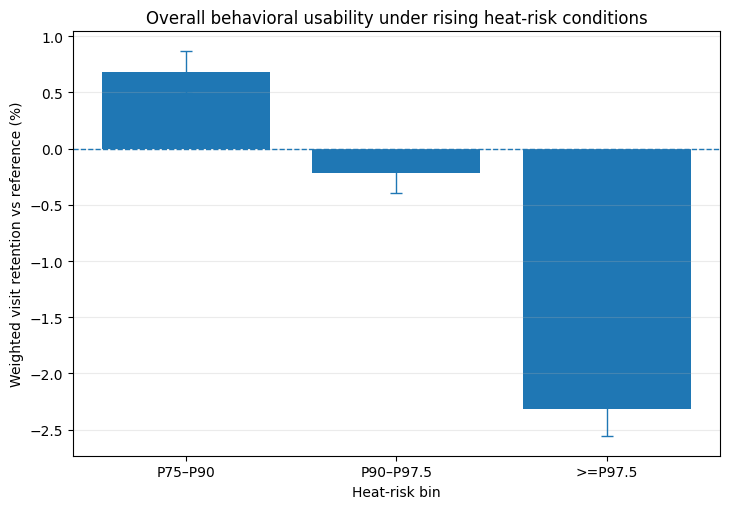

Saved figure:
- /content/gdrive/My Drive/Colab Notebooks/_derived_nature_parks_mainmodel/_results_rq1_overall_usability_heat_bins/figures/figure_rq1_overall_visit_retention_by_heatbin.png
- /content/gdrive/My Drive/Colab Notebooks/_derived_nature_parks_mainmodel/_results_rq1_overall_usability_heat_bins/figures/figure_rq1_overall_visit_retention_by_heatbin.pdf


In [9]:
fig_df = national_retention.copy()
fig_df = fig_df.sort_values("heat_risk_bin")

x = np.arange(len(fig_df))
y = fig_df["weighted_retention_pct"].values
err_low = y - fig_df["weighted_retention_pct_ci_low"].values
err_high = fig_df["weighted_retention_pct_ci_high"].values - y

def _safe_err(a):
    a = np.where(np.isfinite(a), a, 0.0)
    a = np.where(a < 0, 0.0, a)
    return a

err = np.vstack([_safe_err(err_low), _safe_err(err_high)])

fig, ax = plt.subplots(figsize=(7.4, 5.2))
ax.bar(x, y)
ax.errorbar(x, y, yerr=err, fmt="none", capsize=4, linewidth=1.0)
ax.axhline(0, linewidth=1.0, linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels([BIN_LABELS[b] for b in fig_df["heat_risk_bin"]])
ax.set_ylabel("Weighted visit retention vs reference (%)")
ax.set_xlabel("Heat-risk bin")
ax.set_title("Overall behavioral usability under rising heat-risk conditions")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(figure_main_png, dpi=FIG_DPI, bbox_inches="tight")
fig.savefig(figure_main_pdf, dpi=FIG_DPI, bbox_inches="tight")
plt.show()

print("Saved figure:")
print("-", figure_main_png)
print("-", figure_main_pdf)

In [10]:
print("\n" + "=" * 90)
print("RQ1 MAIN TAKEAWAY CHECK")
print("=" * 90)
for _, r in national_retention.iterrows():
    print(
        f"{r['heat_risk_bin_label']}: "
        f"weighted retention = {r['weighted_retention_pct']:.2f}% "
        f"(95% CI {r['weighted_retention_pct_ci_low']:.2f}, {r['weighted_retention_pct_ci_high']:.2f}); "
        f"parks = {int(r['n_parks']):,}"
    )

print("\nOutputs written to:")
print(out_root)


RQ1 MAIN TAKEAWAY CHECK
P75–P90: weighted retention = 0.69% (95% CI 0.50, 0.87); parks = 102,972
P90–P97.5: weighted retention = -0.21% (95% CI -0.39, -0.03); parks = 102,491
>=P97.5: weighted retention = -2.32% (95% CI -2.56, -2.08); parks = 102,524

Outputs written to:
/content/gdrive/My Drive/Colab Notebooks/_derived_nature_parks_mainmodel/_results_rq1_overall_usability_heat_bins
